# Task 3 · Step 2 — Equal-generation group-size study (K ∈ {2, 4, 8})
**Data.** The supplied K-cache: 8 completions with RM rewards for each of 24 held-out prompts (192 generations). For each K the same 192 generations are split into disjoint groups (8/K per prompt), so every condition spends exactly the same generation budget; no training is involved.

**Quantities.** Informative-group rate (reward std above the released helper's tolerance 1e-6), mean within-group reward std, variance of the group-relative signal, and — because a continuous RM reward makes almost every group technically informative — how *reliable* the relative signal is: agreement of each completion's advantage sign with a leave-group-out baseline (mean of the prompt's other cached completions) and the error of the group baseline against it (n/a for K = 8, which uses all completions). Difficulty bins (defined once): tertiles of the prompt's 8-completion mean reward.

**Research question (RQ1).** How does group size change the probability of observing a useful relative signal, and which difficulty regimes benefit most from larger K?


In [1]:
%matplotlib inline
import os, sys, json, re
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "configs").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, yaml
from IPython.display import display, Markdown, HTML, Image
from common.nb_helpers import (style, load, jl, exists, pending, run, side_by_side, ci_text,
                               bootstrap_mean_diff, smooth, full_windows, PALETTE, SEQ, RES, FIG)
from common.metrics import length_stats, wilson_interval
from common.data import load_yaml
style()
print("repo root:", ROOT)

repo root: C:\Users\moize\OneDrive - Higher Education Commission\Desktop\Academics\ATML\PA2


## Run this step (optional)
The results below come from the Kaggle run of the script pipeline (`kaggle_runner.ipynb`). Set `FORCE_RUN = True`
to re-run the step's scripts from here (needs a CUDA GPU and the downloaded course assets).


In [2]:
FORCE_RUN = False
if FORCE_RUN:
    run('python -m task3_grpo.analyze_group_size --config configs/grpo.yaml')
else:
    print('Using saved results under results/ (FORCE_RUN = False).')

Using saved results under results/ (FORCE_RUN = False).


## 1. The cache

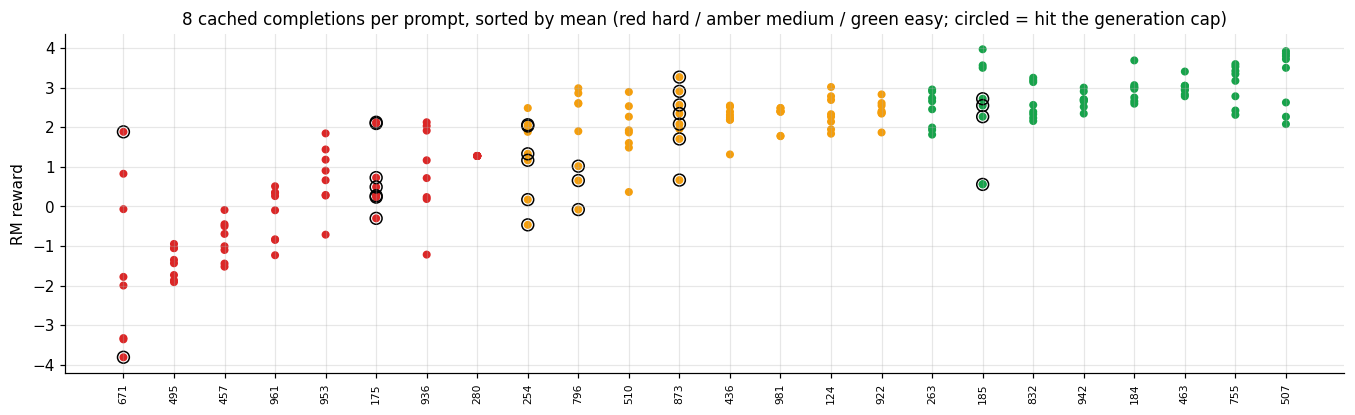

{
 "rule": "tertiles of the 8-completion mean RM reward per prompt",
 "hard_max": 1.3125813802083335,
 "medium_max": 2.4212239583333335
}
capped completions: 29


In [3]:
from task3_grpo.analyze_group_size import load_k8_cache, regroup_equal_generation_budget, group_stats, difficulty_bins
%matplotlib inline
bp = load_k8_cache("cached/grpo_k_cache.jsonl"); bins, means, meta = difficulty_bins(bp)
order = sorted(bp, key=lambda p: means[p])
fig, ax = plt.subplots(figsize=(15, 4))
cols = {"hard": "#DC2626", "medium": "#F59E0B", "easy": "#16A34A"}
for i, p in enumerate(order):
    r = [float(x["reward"]) for x in bp[p][:8]]; cap = [bool(x.get("clipped_at_max")) for x in bp[p][:8]]
    ax.scatter([i] * 8, r, c=[cols[bins[p]]] * 8, marker="o", s=18)
    ax.scatter([i] * sum(cap), [v for v, c in zip(r, cap) if c], facecolors="none", edgecolors="k", s=60)
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=90, fontsize=7); ax.set_ylabel("RM reward")
ax.set_title(f"8 cached completions per prompt, sorted by mean (red hard / amber medium / green easy; circled = hit the generation cap)"); plt.show()
print(json.dumps({k: v for k, v in meta.items()}, indent=1)); print("capped completions:", sum(bool(x.get("clipped_at_max")) for g in bp.values() for x in g))

## 2. Results per K (all prompts and per difficulty bin)

In [4]:
G = load("task3_grpo/grpo_group_size_analysis.json"); KS = [2, 4, 8]
cols_ = ["groups", "informative_group_fraction", "meaningful_group_fraction", "mean_within_group_reward_std", "relative_signal_variance",
         "raw_advantage_variance", "advantage_sign_agreement", "mean_baseline_error", "mean_best_minus_worst", "groups_with_lt2_trainable_after_cap_mask"]
display(pd.DataFrame({f"K={k}": {c: G[str(k)].get(c) for c in cols_} for k in KS}).round(4))
rows = []
for k in KS:
    for dname in ["hard", "medium", "easy"]:
        s = G[str(k)]["difficulty_breakdown"][dname]
        rows.append({"K": k, "difficulty": dname, **{c: s.get(c) for c in ["groups", "informative_group_fraction", "meaningful_group_fraction",
                                                                          "mean_within_group_reward_std", "advantage_sign_agreement", "mean_baseline_error"]}})
pd.DataFrame(rows).set_index(["difficulty", "K"]).sort_index().round(4)

,K=2,K=4,K=8
groups,96.0000,48.0000,24.0000
informative_group_fraction,0.9375,0.9583,0.9583
meaningful_group_fraction,0.7604,0.9375,0.9583
mean_within_group_reward_std,0.3846,0.5410,0.6191
relative_signal_variance,0.9375,0.9583,0.9583
raw_advantage_variance,0.3368,0.4677,0.5599
advantage_sign_agreement,0.6771,0.7292,NaN
mean_baseline_error,0.4426,0.4276,NaN
mean_best_minus_worst,0.7691,1.3713,1.8560
groups_with_lt2_trainable_after_cap_mask,18.0000,6.0000,2.0000


groups  informative_group_fraction  meaningful_group_fraction  mean_within_group_reward_std  advantage_sign_agreement  mean_baseline_error
difficulty K                                                                                                                                            
easy       2      32                      1.0000                     0.7188                        0.2479                    0.6875               0.4038
           4      16                      1.0000                     1.0000                        0.4098                    0.7969               0.3997
           8       8                      1.0000                     1.0000                        0.4948                       NaN                  NaN
hard       2      32                      0.8438                     0.7500                        0.4934                    0.6094               0.5482
           4      16                      0.8750                     0.8750                        0.6615                    0.6250               0.5468
           8       8                      0.8750                     0.8750                        0.7634                       NaN                  NaN
medium     2      32                      0.9688                     0.8125                        0.4124                    0.7344               0.3757
           4      16                      1.0000                     0.9375                        0.5517                    0.7656               0.3362
           8       8                      1.0000                     1.0000                        0.5990                       NaN                  NaN

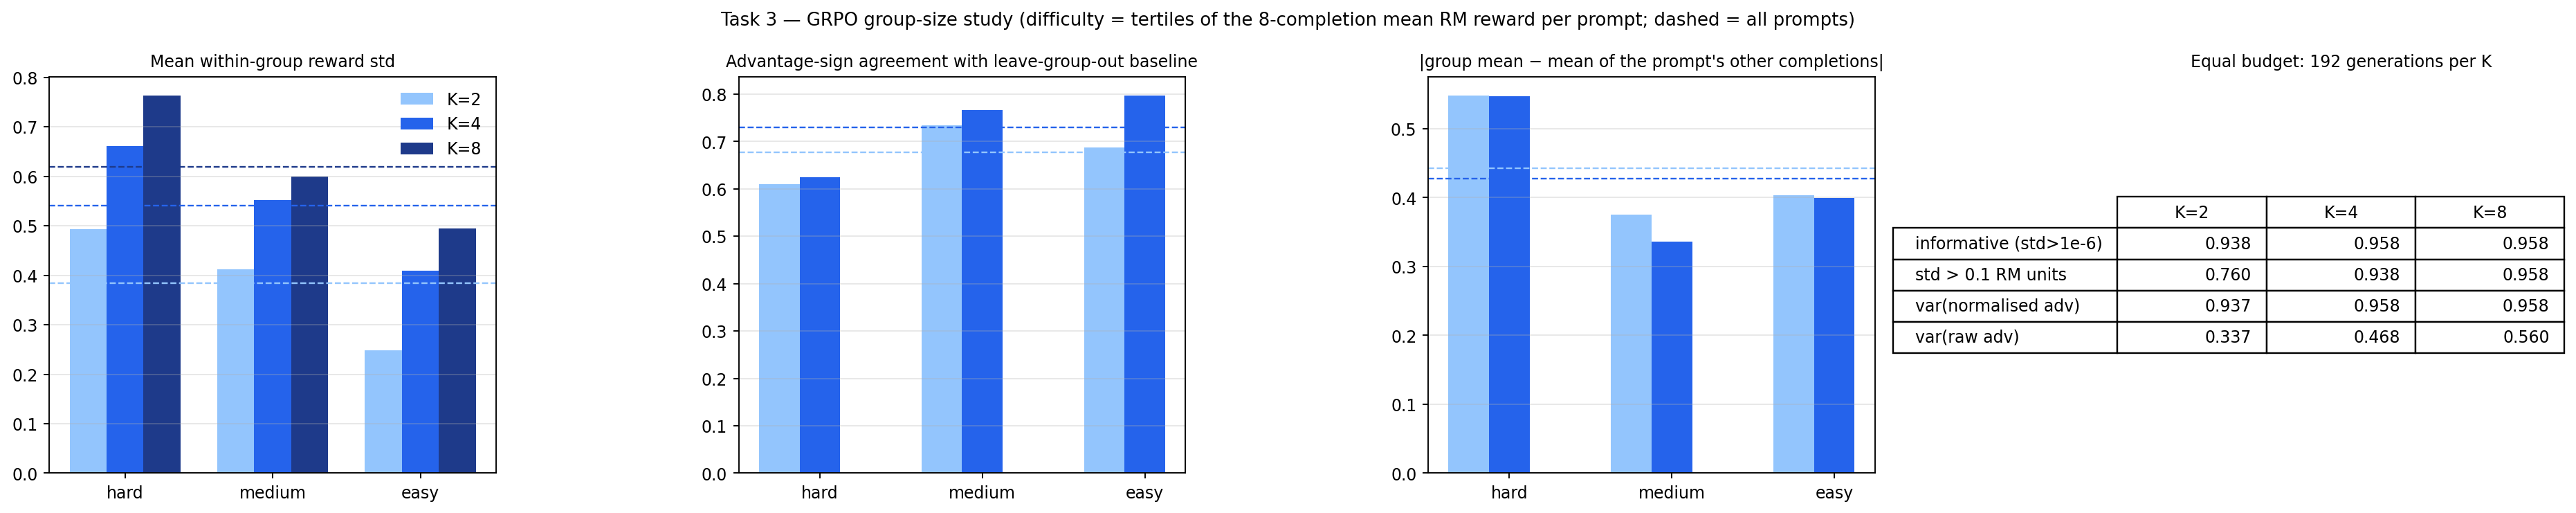

In [5]:
display(Image(filename=str(FIG / "task3_grpo_group_size_study.png"), width=1100))

## 3. Sensitivity to the std threshold that counts a group as informative

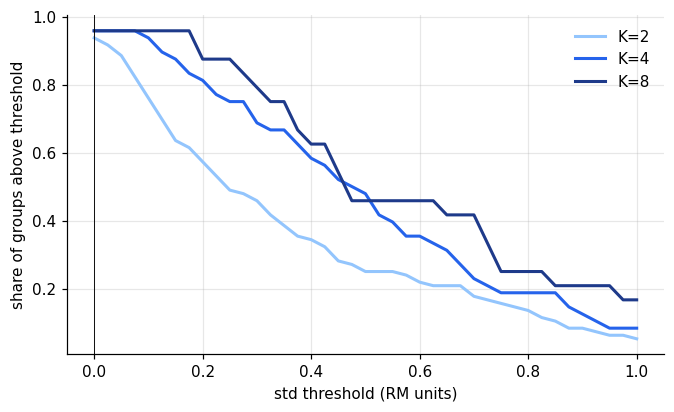

In [6]:
th = np.linspace(0, 1.0, 41)
fig, ax = plt.subplots(figsize=(7, 4))
for k, c in zip(KS, SEQ):
    stds = np.array([np.std([float(x["reward"]) for x in g]) for g in regroup_equal_generation_budget(bp, k)])
    ax.plot(th, [(stds > t).mean() for t in th], color=c, lw=2, label=f"K={k}")
ax.axvline(1e-6, color="k", lw=0.6); ax.set_xlabel("std threshold (RM units)"); ax.set_ylabel("share of groups above threshold"); ax.legend(); plt.show()

## 4. One prompt under the three groupings

In [7]:
p = order[len(order) // 2]; r = np.array([float(x["reward"]) for x in bp[p][:8]])
tab = pd.DataFrame({"completion": range(8), "reward": r.round(3), "sign vs mean of the other 7": np.sign(r - (r.sum() - r) / 7).astype(int)})
for k in [2, 4, 8]:
    adv = np.concatenate([(r[s:s + k] - r[s:s + k].mean()) / (r[s:s + k].std() + 1e-6) for s in range(0, 8, k)])
    tab[f"A (K={k})"] = adv.round(2)
print(f"prompt {p} ({bins[p]}), mean reward {means[p]:.3f}"); tab

prompt 436 (medium), mean reward 2.213


,completion,reward,sign vs mean of the other 7,A (K=2),A (K=4),A (K=8)
0,0,2.516,1,1.0,0.72,0.83
1,1,2.250,1,-1.0,0.19,0.10
2,2,1.312,-1,-1.0,-1.69,-2.48
3,3,2.547,1,1.0,0.78,0.92
4,4,2.188,-1,-1.0,-0.95,-0.07
5,5,2.391,1,1.0,1.40,0.49
6,6,2.188,-1,-1.0,-0.95,-0.07
7,7,2.312,1,1.0,0.50,0.27


## 5. Facts for RQ1

In [8]:
for k in KS:
    s = G[str(k)]
    print(f"K={k}: informative {s['informative_group_fraction']:.3f}, std>0.1 {s['meaningful_group_fraction']:.3f}, mean std {s['mean_within_group_reward_std']:.3f}, "
          f"sign agreement {s['advantage_sign_agreement']}, baseline error {s['mean_baseline_error']}; by difficulty sign agreement: "
          + ", ".join(f"{d} {s['difficulty_breakdown'][d].get('advantage_sign_agreement')}" for d in ["hard", "medium", "easy"]))

K=2: informative 0.938, std>0.1 0.760, mean std 0.385, sign agreement 0.6770833333333334, baseline error 0.4425642225477431; by difficulty sign agreement: hard 0.609375, medium 0.734375, easy 0.6875
K=4: informative 0.958, std>0.1 0.938, mean std 0.541, sign agreement 0.7291666666666666, baseline error 0.42755126953125; by difficulty sign agreement: hard 0.625, medium 0.765625, easy 0.796875
K=8: informative 0.958, std>0.1 0.958, mean std 0.619, sign agreement None, baseline error None; by difficulty sign agreement: hard None, medium None, easy None
